In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#### Fine-tuning results:

In [2]:
# Minute-level variables only: 
# Best Hyperparameters: 
# {'WINDOW_SIZE': 50, 'NUM_NEURONS': 80, 'DROPOUT_RATE': 0.45000000000000007, 
# 'PATIENCE': 8, 'EPOCHS': 110, 'BATCH_SIZE': 64, 'LEARNING_RATE': 0.00010734428790609837}

In [3]:
# Define global environment variables

# Train-val-test split (70% training, 20% validation, 10% test)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

import math
assert math.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0), "Splits must sum to 1.0"

# Model hyperparameters (fine-tuned)
WINDOW_SIZE = 50
NUM_NEURONS = 80
DROPOUT_RATE = 0.45
PATIENCE = 8
EPOCHS = 110
BATCH_SIZE = 64

## Data analysis

In [4]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/Bitcoin_data_full.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [5]:
# Only select minute-level data
data = data[['open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD']]

In [6]:
data

,open,high,low,close,Volume BTC,Volume USD
date,,,,,,
2024-01-31 00:00:00,42945.0,42989.0,42933.0,42984.0,5.160732,221828.915894
2024-01-31 00:01:00,42981.0,43056.0,42981.0,43056.0,7.969300,343126.169175
2024-01-31 00:02:00,43056.0,43098.0,43022.0,43022.0,9.561501,411354.902045
2024-01-31 00:03:00,43019.0,43029.0,43005.0,43005.0,0.598142,25723.117782
2024-01-31 00:04:00,43002.0,43031.0,43002.0,43006.0,0.941927,40508.530194
...,...,...,...,...,...,...
2024-12-31 23:55:00,93476.0,93476.0,93471.0,93471.0,0.179799,16805.981112
2024-12-31 23:56:00,93469.0,93469.0,93469.0,93469.0,0.021400,2000.236600
2024-12-31 23:57:00,93462.0,93462.0,93413.0,93427.0,0.034750,3246.554616


In [7]:
data.describe()

,open,high,low,close,Volume BTC,Volume USD
count,468137.000000,468137.000000,468137.000000,468137.000000,468137.000000,4.681370e+05
mean,67890.318246,67909.914518,67870.729838,67890.503148,1.520545,1.053285e+05
std,13432.878987,13436.311211,13429.015271,13432.602482,5.008833,3.588237e+05
min,41865.000000,41889.000000,41859.000000,41874.000000,0.000000,0.000000e+00
25%,60742.000000,60757.000000,60727.000000,60742.000000,0.028262,1.834179e+03
50%,65100.000000,65121.000000,65080.000000,65101.000000,0.205836,1.366887e+04
75%,69380.000000,69392.000000,69366.000000,69379.000000,0.866575,5.831529e+04
max,108293.000000,108364.000000,108204.000000,108276.000000,325.202458,3.022984e+07


In [8]:
# The number of missing values 
data.isna().sum()

open          0
high          0
low           0
close         0
Volume BTC    0
Volume USD    0
dtype: int64

## Data processing

In [9]:
# Train-val-test split 
train_ratio = TRAIN_RATIO
val_ratio = VAL_RATIO
test_ratio = TEST_RATIO

# Compute split indices
train_index = int(len(data) * train_ratio)
val_index = train_index + int(len(data) * val_ratio)

# Perform the splits
train_data = data.iloc[:train_index]                    
val_data = data.iloc[train_index:val_index]             
test_data = data.iloc[val_index:]                      

# Print the shapes to confirm
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (327695, 6)
Validation shape: (93627, 6)
Test shape: (46815, 6)


In [10]:
# Ensure WINDOW_SIZE does not exceed dataset length
assert WINDOW_SIZE < len(train_data), "WINDOW_SIZE is too large for the dataset size!"

In [11]:
print("Train start:", train_data.index[0], "end:", train_data.index[-1])
print("Val start:", val_data.index[0], "end:", val_data.index[-1])
print("Test start:", test_data.index[0], "end:", test_data.index[-1])

Train start: 2024-01-31 00:00:00 end: 2024-09-21 12:23:00
Val start: 2024-09-21 12:24:00 end: 2024-11-27 17:01:00
Test start: 2024-11-27 17:02:00 end: 2024-12-31 23:59:00


In [12]:
# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(train_data) # Fit only on training data

# Transform train, validation, and test data using the fitted scaler
train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)  

In [13]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [14]:
# Define window size and target column
window_size = WINDOW_SIZE 
target_col = 'close'
target_col_idx = data.columns.get_loc(target_col)

# Create sequences for training, validation and test sets
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)
X_test, y_test = create_sequences(test_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(327645, 50, 6) (327645,)
(93577, 50, 6) (93577,)
(46765, 50, 6) (46765,)


## Model training (GRU)

In [15]:
# Define GRU model
gru_model = Sequential([
    GRU(NUM_NEURONS, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    Dense(1) # Predicting the close price
])
gru_model.compile(optimizer=Adam(learning_rate = 0.00010734428790609837), loss='mean_squared_error')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 80)             │        21,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,201 (82.82 KB)

 Trainable params: 21,201 (82.82 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# Train the model
history = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.0152 - val_loss: 3.7901e-04
Epoch 2/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 0.0024 - val_loss: 8.8771e-05
Epoch 3/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 9.9540e-04 - val_loss: 9.2367e-06
Epoch 4/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - loss: 5.5396e-04 - val_loss: 2.3395e-05
Epoch 5/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 59s 11ms/step - loss: 4.8469e-04 - val_loss: 8.0785e-06
Epoch 6/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 4.7892e-04 - val_loss: 1.3659e-05
Epoch 7/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 59s 12ms/step - loss: 4.6650e-04 - val_loss: 2.5088e-05
Epoch 8/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 4.5693e-04 - val_loss: 2.0644e-04
Epoch 9/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 60s 12ms/step - loss: 4.5836e-04 - val_loss: 8.9179e-06
Epoch 10/110
5120/5120 ━━━━━━━━━━━━━━━━━━━━ 64s 13ms/step - loss: 4.5090e-04 - val_loss: 1.6618e-05
Epoch 11/110
5120

In [17]:
# Training and validation loss
history.history.keys()

dict_keys(['loss', 'val_loss'])

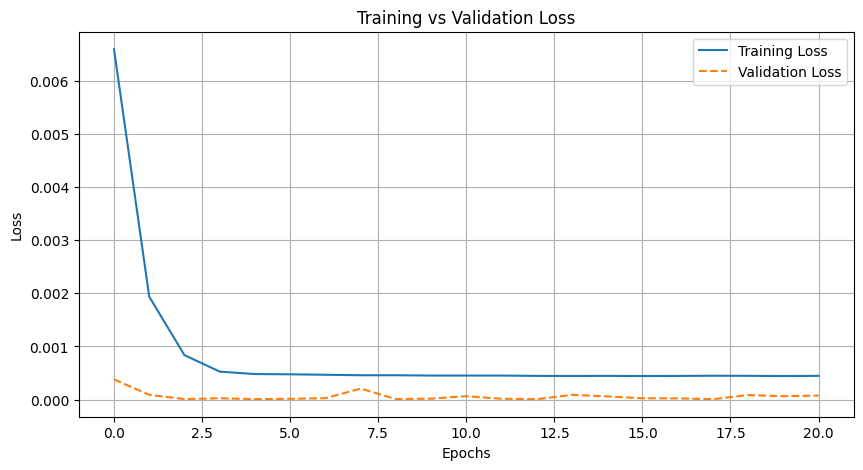

In [18]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation 

In [19]:
# Crate an inverse function
def inverse_transform_predictions(predicted_scaled, y_actual_scaled, scaler, train_data, target_col_idx):
    """
    Inverse transforms the scaled predictions and actual values back to the original scale.

    Parameters:
    - predicted_scaled: Model predictions in scaled form (shape: (n_samples, 1)).
    - y_actual_scaled: Actual target values in scaled form (shape: (n_samples,)).
    - scaler: The MinMaxScaler fitted on the training data.
    - train_data: The original training dataset (used to get the number of features for inverse transform).
    - target_col_idx: The index of the target column in the dataset.

    Returns:
    - predicted_inverse: Predictions in the original scale.
    - y_actual_inverse: Actual values in the original scale.
    """

    # Create full arrays with the same shape as train_data for inverse transformation
    predicted_full = np.zeros((predicted_scaled.shape[0], train_data.shape[1]))
    y_actual_full = np.zeros((y_actual_scaled.shape[0], train_data.shape[1]))

    # Fill only the target column ('close' price)
    predicted_full[:, target_col_idx] = predicted_scaled[:, 0]  # Ensure correct shape
    y_actual_full[:, target_col_idx] = y_actual_scaled  # y_actual is already 1D

    # Apply inverse transform
    predicted_inverse = scaler.inverse_transform(predicted_full)[:, target_col_idx]
    y_actual_inverse = scaler.inverse_transform(y_actual_full)[:, target_col_idx]

    return predicted_inverse, y_actual_inverse

### Training set evaluation 

In [20]:
# Get inverse transformed predictions and actual values
predicted_train_inverse, y_train_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_train),
    y_actual_scaled=y_train,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

10239/10239 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


In [21]:
# Compute error metrics for the training set
mae_train = mean_absolute_error(y_train_inverse, predicted_train_inverse)
rmse_train = sqrt(mean_squared_error(y_train_inverse, predicted_train_inverse))
mape_train = np.mean(np.abs((y_train_inverse - predicted_train_inverse) / y_train_inverse)) * 100  

print(f"Train MAE: {mae_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAPE: {mape_train:.2f}%")

Train MAE: 44.1993
Train RMSE: 62.2870
Train MAPE: 0.07%


### Validation set evaluation 

In [22]:
# Get inverse transformed predictions and actual values
predicted_val_inverse, y_val_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_val),
    y_actual_scaled=y_val,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

2925/2925 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [23]:
# Compute error metrics for the val set
mae_val = mean_absolute_error(y_val_inverse, predicted_val_inverse)
rmse_val = sqrt(mean_squared_error(y_val_inverse, predicted_val_inverse))
mape_val = np.mean(np.abs((y_val_inverse - predicted_val_inverse) / y_val_inverse)) * 100  

print(f"Validation MAE: {mae_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Validation MAPE: {mape_val:.2f}%")

Validation MAE: 54.0550
Validation RMSE: 77.0767
Validation MAPE: 0.07%


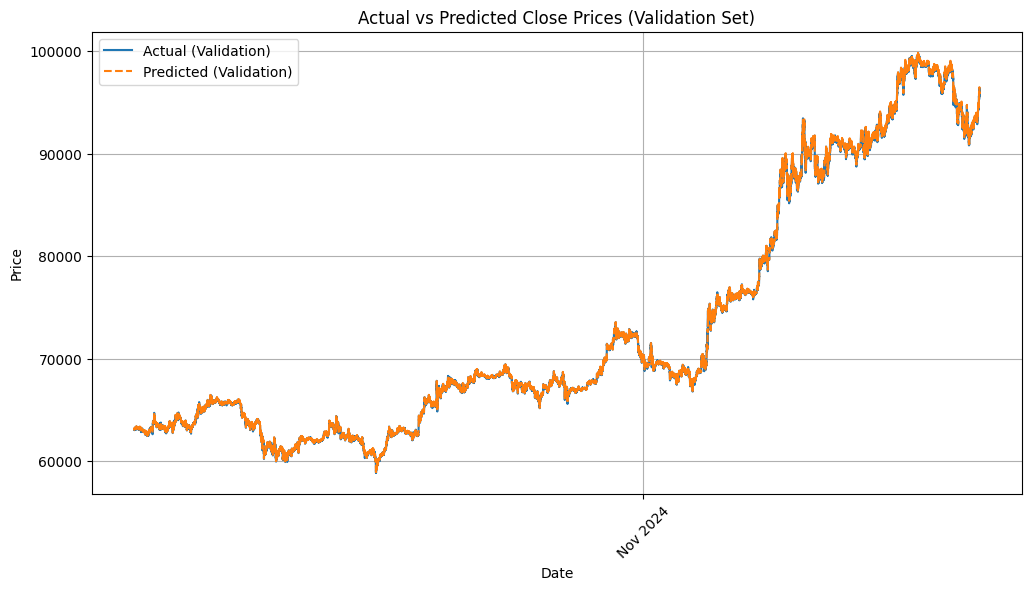

In [24]:
# Extract date index for plotting
date_index = val_data.index[window_size:]  # Align with sequence offset

# Plot actual vs predicted close prices for validation set
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='Predicted (Validation)', linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Benchmark against a Naïve Forecast

In [25]:
val_data.head()

,open,high,low,close,Volume BTC,Volume USD
date,,,,,,
2024-09-21 12:24:00,63068.0,63068.0,63068.0,63068.0,0.008380,528.538851
2024-09-21 12:25:00,63052.0,63053.0,63049.0,63053.0,0.015550,980.444515
2024-09-21 12:26:00,63053.0,63053.0,63053.0,63053.0,0.000000,0.000000
2024-09-21 12:27:00,63056.0,63056.0,63056.0,63056.0,0.005768,363.684938
2024-09-21 12:28:00,63054.0,63054.0,63054.0,63054.0,0.000379,23.880441


In [26]:
actual_val = val_data['close']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_val.iloc[window_size - 1:-1].values
actual_val_values = actual_val.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_val_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_val_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_val_values - naive_predictions) / actual_val_values)) * 100

print(f"Validation Naive MAE: {mae_naive:.4f}")
print(f"Validation Naive RMSE: {rmse_naive:.4f}")
print(f"Validation Naive MAPE: {mape_naive:.2f}%")

Validation Naive MAE: 31.9031
Validation Naive RMSE: 51.7864
Validation Naive MAPE: 0.04%


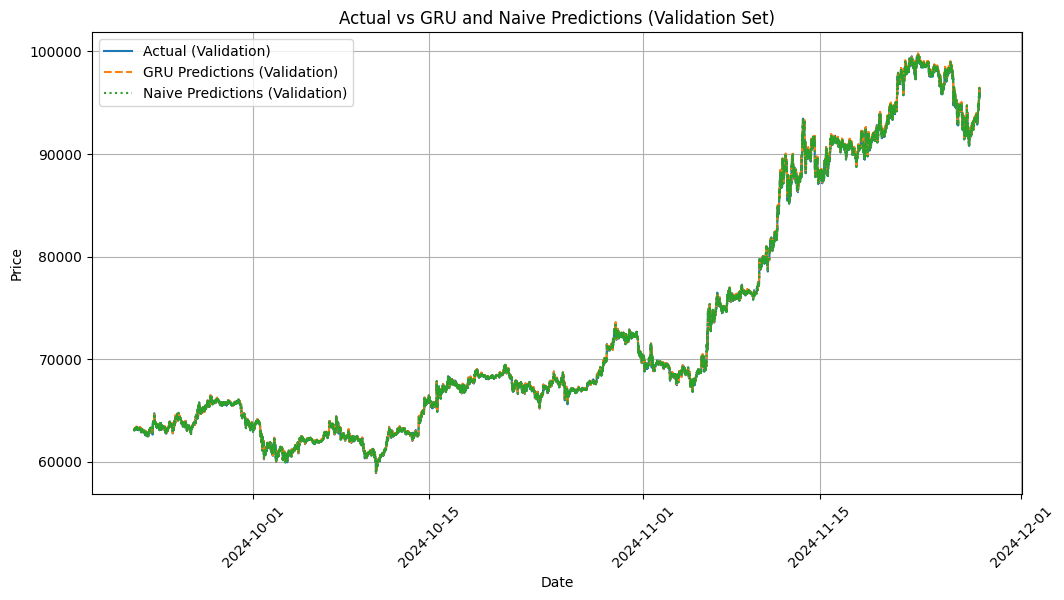

In [27]:
# Prepare a date index for plotting (adjusting for the sequence offset)
date_index = val_data.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='GRU Predictions (Validation)', linestyle='dashed')
plt.plot(date_index, naive_predictions, label='Naive Predictions (Validation)', linestyle='dotted')
plt.title('Actual vs GRU and Naive Predictions (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()